# Customer Satisfaction Survey Participation Analysis
## Notebook 01 – Data Preparation and Customer Segmentation

**Author:** Pei-Pei Lei

**Last Updated:** 06/28/2026

---
## Project Objective

This notebook transforms the synthetic survey participation dataset into an analysis-ready dataset for exploratory analysis and predictive modeling.

Building upon the synthetic data generated in Notebook 00, this notebook reviews historical survey participation patterns, creates analytically meaningful customer segments, and produces summary outputs that will be used throughout the remainder of the project.

The processed dataset developed in this notebook serves as the analytical foundation for the business insights and predictive models presented in subsequent notebooks.

Specifically, this notebook will:

- Load the synthetic survey participation dataset.
- Review historical survey participation patterns.
- Create mutually exclusive customer segments based on response history.
- Calculate response rates across customer segments and geographic groups.
- Generate summary tables to validate the segmentation.
- Validate the customer segmentation by evaluating differences in survey participation across customer segments.
---

### Segmentation Strategy

**Prior Responders**
- Surveyed in the previous two years
- Responded at least once

**Silent Customers**
- Surveyed in the previous two years
- Never responded

**New Customers**
- Not surveyed in the previous two years

---

### Analytical Outputs

The notebook will produce:

- Customer segment counts
- Response rates by customer segment
- Response rates by geographic group
- Summary tables for exploratory analysis and visualization
- Statistical comparison of response rates across customer segments

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
## Create folder structure- one time code
## Manually created "notebooks" to host this notebook

## un-comment out following codes if needed

##os.makedirs("data/raw", exist_ok=True)
##os.makedirs("data/processed", exist_ok=True)
##os.makedirs("outputs", exist_ok=True)

In [3]:
from pathlib import Path

# ---------------------------------------------------------------------
# Project Paths
# ---------------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
DATA_RAW = DATA_DIR / "raw"
DATA_PROCESSED = DATA_DIR / "processed"

DATA_OUTPUTS = PROJECT_ROOT / "outputs"

# Create output directories if they do not exist
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
DATA_OUTPUTS.mkdir(parents=True, exist_ok=True)

In [4]:
## Read in raw data
df = pd.read_csv(DATA_RAW / "survey_participation_data.csv")
df.head()

,customer_id,survey_year,customer_segment,in_out_state,responded
0,C000001,FY25,Silent Customers,In-State,0
1,C000002,FY25,Silent Customers,In-State,0
2,C000003,FY25,Silent Customers,In-State,1
3,C000004,FY25,Silent Customers,In-State,0
4,C000005,FY25,Silent Customers,In-State,1


## Review Dataset Structure

In [5]:
df.shape

(1200, 5)

In [6]:
df.isna().sum()

customer_id         0
survey_year         0
customer_segment    0
in_out_state        0
responded           0
dtype: int64

The synthetic dataset was intentionally generated without missing values.

Nevertheless, these validation steps demonstrate a standard analytical workflow that would also apply to real-world survey datasets.

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

customer_id           str
survey_year           str
customer_segment      str
in_out_state          str
responded           int64
dtype: object

In [9]:
df.describe(include="all")

,customer_id,survey_year,customer_segment,in_out_state,responded
count,1200,1200,1200,1200,1200.000000
unique,1200,2,3,2,NaN
top,C000001,FY25,Prior Responders,In-State,NaN
freq,1,600,500,1000,NaN
mean,NaN,NaN,NaN,NaN,0.470833
std,NaN,NaN,NaN,NaN,0.499357
min,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,1.000000


## Do customer segments exhibit consistent response patterns across survey years?

### Calculate response rate by customer segments and survey years

In [10]:
response_summary = (
    df
    .groupby(["survey_year", "customer_segment"])
    .agg(
        customers=("customer_id", "count"),
        response_rate=("responded", "mean")
    )
    .reset_index()
)

response_summary

,survey_year,customer_segment,customers,response_rate
0,FY25,New Customers,200,0.365000
1,FY25,Prior Responders,250,0.692000
2,FY25,Silent Customers,150,0.286667
3,FY26,New Customers,170,0.376471
4,FY26,Prior Responders,250,0.704000
5,FY26,Silent Customers,180,0.200000


In [11]:
plot_data = (
    response_summary
    .pivot(
        index="customer_segment",
        columns="survey_year",
        values="response_rate"
    )
)

#re-index segmeent order to match the order we're using in this notebook
segment_order = [
    "Prior Responders",
    "New Customers",
    "Silent Customers"
]
plot_data = plot_data.reindex(segment_order)

# Display response rates as percentages (without changing the underlying data)
plot_data.style.format("{:.1%}")

survey_year,FY25,FY26
customer_segment,,
Prior Responders,69.2%,70.4%
New Customers,36.5%,37.6%
Silent Customers,28.7%,20.0%


### Show response rates in each segments by year

### Response rate for FY25 responses

In [12]:
fy25 = (
    response_summary[
        response_summary["survey_year"] == "FY25"
    ]
    .sort_values("response_rate", ascending=False)
)
#show fy25 with response_rate in % format, hide index
fy25.style.hide(axis="index").format({
    "response_rate": "{:.1%}"
})

survey_year,customer_segment,customers,response_rate
FY25,Prior Responders,250,69.2%
FY25,New Customers,200,36.5%
FY25,Silent Customers,150,28.7%



### Response rate for FY26 responses

In [13]:
fy26 = (
    response_summary[
        response_summary["survey_year"] == "FY26"
    ]
    .sort_values("response_rate", ascending=False)
)
#show fy26 with response_rate in % format, hide index
fy26.style.hide(axis="index").format({
    "response_rate": "{:.1%}"
})

survey_year,customer_segment,customers,response_rate
FY26,Prior Responders,250,70.4%
FY26,New Customers,170,37.6%
FY26,Silent Customers,180,20.0%


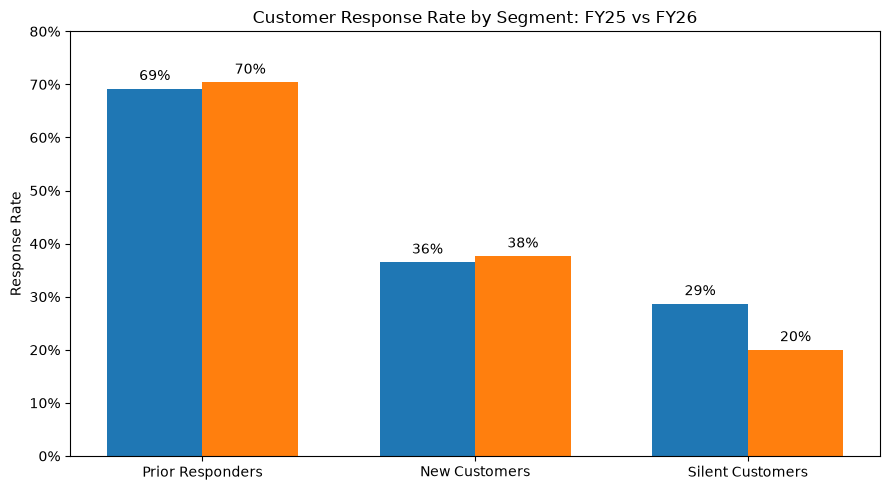

In [14]:
x = np.arange(len(plot_data.index))
width = 0.35

fig, ax = plt.subplots(figsize=(9,5))

bars1 = ax.bar(
    x - width/2,
    plot_data["FY25"],
    width,
    label="FY25"
)

bars2 = ax.bar(
    x + width/2,
    plot_data["FY26"],
    width,
    label="FY26"
)

ax.set_title("Customer Response Rate by Segment: FY25 vs FY26")

ax.set_ylabel("Response Rate")

ax.set_xticks(x)

ax.set_xticklabels(plot_data.index)

ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(1)
)

ax.set_ylim(0,0.8)

ax.legend

## add numbers on top of the bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,          # slightly above the bar
            f"{height:.0%}",        # display as percentage (e.g., 72%)
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.tight_layout()
plt.show()

## Validate Customer Segmentation
### Evaluate Differences in Survey Participation Across Customer Segments

## Assess the Predictive Value of Customer Segmentation

Customer segmentation is intended to capture differences in survey participation behavior based on respondents' historical response patterns.

To determine whether these predefined customer segments provide meaningful analytical value, response rates are compared across segments for each survey year.

Descriptive statistics, data visualizations, and statistical testing are used to evaluate whether survey participation differs significantly among customer segments. If meaningful differences are observed, customer segmentation will be retained as an important predictor for subsequent predictive modeling.

 ### Statistical Validation

Although differences in response rates are visually apparent, statistical testing is required to determine whether these differences are unlikely to have occurred by chance.

A Chi-square test of independence is used to evaluate the association between customer segment and survey participation.

In [15]:
from scipy.stats import chi2_contingency
#import pandas as pd

# Create FY25 individual-level dataset
fy25_raw = df[df["survey_year"] == "FY25"].copy()

# Create contingency table
fy25_contingency_table = pd.crosstab(
    fy25_raw["customer_segment"],
    fy25_raw["responded"]
)

fy25_contingency_table

responded,0,1
customer_segment,,
New Customers,127,73
Prior Responders,77,173
Silent Customers,107,43


In [16]:
from scipy.stats import chi2_contingency
#import pandas as pd

# Create FY26 individual-level dataset
fy26_raw = df[df["survey_year"] == "FY26"].copy()

# Create contingency table
fy26_contingency_table = pd.crosstab(
    fy26_raw["customer_segment"],
    fy26_raw["responded"]
)

fy26_contingency_table

responded,0,1
customer_segment,,
New Customers,106,64
Prior Responders,74,176
Silent Customers,144,36


While the response rate differences appear substantial, visual inspection alone cannot determine whether these differences are statistically meaningful.

Therefore, a Chi-square test of independence is conducted to evaluate whether survey participation is associated with customer segment.

In [17]:
# Run Chi-square test for FY25 data
chi2, p, dof, expected = chi2_contingency(fy25_contingency_table)

print ("Chi-square test for FY25 data")
print(f"Chi-square Statistic : {chi2:.2f}")
print(f"Degrees of Freedom   : {dof}")
print(f"P-value              : {p:.4f}")

Chi-square test for FY25 data
Chi-square Statistic : 78.05
Degrees of Freedom   : 2
P-value              : 0.0000


In [18]:
# Run Cramer's V on FY25 data to get association
n = fy25_contingency_table.to_numpy().sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(fy25_contingency_table.shape) - 1))
)

print(f"Cramer's V           : {cramers_v:.3f}")

Cramer's V           : 0.361


In [19]:
# Run Chi-square test for FY26 data
chi2, p, dof, expected = chi2_contingency(fy26_contingency_table)

print ("Chi-square test for FY26 data")
print(f"Chi-square Statistic : {chi2:.2f}")
print(f"Degrees of Freedom   : {dof}")
print(f"P-value              : {p:.4f}")

Chi-square test for FY26 data
Chi-square Statistic : 113.68
Degrees of Freedom   : 2
P-value              : 0.0000


In [20]:
# Run Cramer's V on FY26 data to get association
n = fy26_contingency_table.to_numpy().sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(fy26_contingency_table.shape) - 1))
)

print(f"Cramer's V           : {cramers_v:.3f}")

Cramer's V           : 0.435


### Interpretation

The Chi-square test indicates a statistically significant association between customer segment and survey participation in both FY25 (χ² = 78.05, p < 0.001) and FY26 (χ² = 113.68, p < 0.001).

The corresponding Cramer's Vs (0.361 for FY25 and 0.435 for FY26) indicate a moderate association, suggesting that historical response behavior is meaningfully associated with future survey participation.

These findings are consistent with the descriptive summaries and visualizations presented earlier. Prior Responders consistently exhibited the highest response rates, while Silent Customers demonstrated the lowest participation.

Together, these results support retaining customer segmentation as an important predictor in subsequent predictive modeling.

## Key Finding

Prior response history was strongly associated with future survey participation.

Customers who responded to surveys in the previous two years had a 71% response rate in FY26, compared with 38% among new customers and only 20% among silent customers.

These findings suggest that prior response behavior is a strong predictor of future participation and may be useful for identifying groups that require targeted outreach strategies.

In [21]:
fy25 = survey[survey["year"] == 2025]

contingency25 = fy25[
    ["n_responded","n_not_responded"]
]

contingency25

NameError: name 'survey' is not defined

In [ ]:
chi2, p, dof, expected = chi2_contingency(
    contingency25
)

print(f"Chi-square statistic = {chi2:.2f}")
print(f"Degrees of freedom = {dof}")
print(f"P-value = {p:.6f}")

if p < 0.05:
    print(
        "Response rates differ significantly across customer segments."
    )
else:
    print(
        "No statistically significant differences were detected."
    )

## Statistical Findings

A chi-square test of independence was conducted to evaluate whether response behavior differed across customer segments.

FY25 results indicated a statistically significant association between customer segment and survey participation:

χ²(2) = 31.44, p < .001.

These findings support the conclusion that prior response history is strongly associated with future survey participation behavior.


## Overall Conclusions

Across both FY25 and FY26 survey cycles, prior survey response history was consistently associated with future participation behavior.

Customers who had responded to previous surveys demonstrated substantially higher response rates than both silent and new customers. Chi-square tests confirmed that these differences were statistically significant in both years.

These findings suggest that historical response behavior can be used to identify customer groups at higher risk of nonresponse and inform targeted survey engagement strategies.